In [32]:
import os # Import list 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from matplotlib.image import imread

sns.set_style("white")

In [33]:
work_dir = os.getcwd() 
work_dir  # Shows working directory 

'/workspaces/XrayFractureClass/jupytr_notebooks'

In [34]:
my_data_dir = '../data/test/' # stores folders as varaibles for later use
train_path = os.path.join(my_data_dir, 'train')
val_path = os.path.join(my_data_dir,  'validation')
test_path = os.path.join(my_data_dir, 'test')

In [35]:
version = 'v2'#Makes the cnn name
file_path = os.path.join ('outputs',version) # makes the filepath

if 'outputs' in os.listdir(work_dir) and version in os.listdir(work_dir + '/outputs'): #checks they exsist
    print(' An older version exsists, number can be updated')
    pass
else:
    Path(file_path).mkdir(parents=True, exist_ok=True)

 An older version exsists, number can be updated


In [36]:
labels = os.listdir(train_path)
print('Label for the images are', labels) # Shows whats in the training path

Label for the images are ['normal', 'fracture']


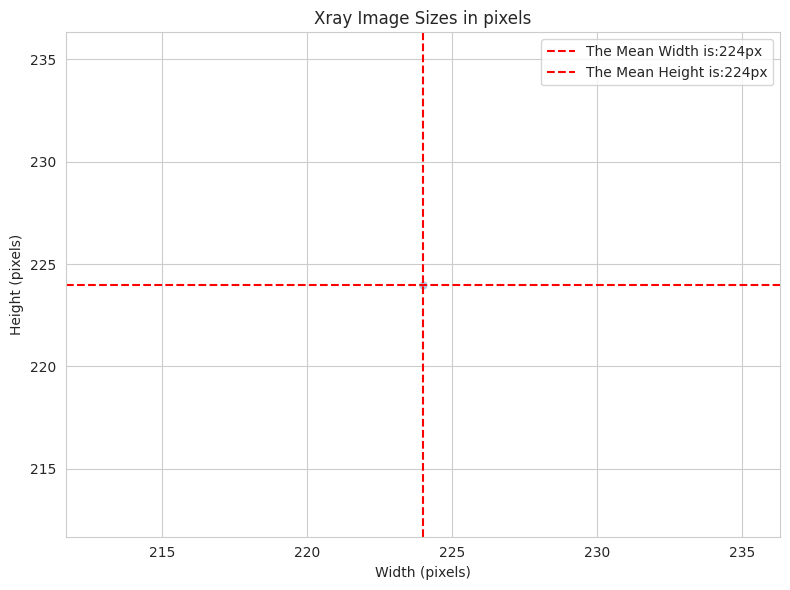

The adverage width: 224 
The average height: 224


In [37]:
train_path ='/workspaces/XrayFractureClass/data/raw/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train'
labels = os.listdir(train_path)

Working_Img_Extentions = ('.jpg', '.jpeg','.png','.bmp','.tiff','.tif')
height, width = [], []

for label in labels:
    label_path = os.path.join(train_path, label)
    if not os.path.isdir(label_path):
        continue
    for image_filename in os.listdir(label_path):
        if not image_filename.lower().endswith(Working_Img_Extentions):
            continue
    img_path = os.path.join(label_path, image_filename)
    try:
        img = imread(img_path)
    except Exception as e:
        print (f"Skiping this non working image {image_filename}: {e}")
        continue
    if img.ndim == 2:
            h, w = img.shape
    elif img.ndim ==3:
            h, w, _ = img.shape
    else:
         continue
    height.append(h)
    width.append(w)
    
height_mean = int(np.array(height).mean())
width_mean = int(np.array(width).mean()) 

sns.set_style("whitegrid")
fig, axes = plt.subplots(figsize=(8, 6))
sns.scatterplot(x=width, y=height, alpha=0.2, ax=axes)
axes.set_xlabel("Width (pixels)")
axes.set_ylabel("Height (pixels)")
axes.set_title("Xray Image Sizes in pixels")
axes.axhline(y=height_mean, color='r', linestyle='--', label=f"The Mean Width is:{height_mean}px")
axes.axvline(x=width_mean, color='r', linestyle='--', label = f"The Mean Height is:{width_mean}px")
axes.legend()
plt.tight_layout()
plt.show()

print(f"The adverage width: {width_mean} \nThe average height: {height_mean}")


In [38]:
image_shape = (height_mean, width_mean, 3)
image_shape

(224, 224, 3)

In [39]:
joblib.dump(value=image_shape ,filename=os.path.join(file_path, 'image_shape.pk1'))

['outputs/v2/image_shape.pk1']

In [40]:
from tensorflow.keras.preprocessing import image

def load_image_as_array(my_data_dir, new_size=(50, 50), n_images_per_label=20):

    X, y = np.array([], dtype='int'), np.array([], dtype='object')
    labels = os.listdir(my_data_dir)

    for label in labels:
        counter = 0
        for image_filename in os.listdir(my_data_dir + '/' + label):
            # Limit to prevent wasted time
            if counter < n_images_per_label:
                img = image.load_img(os.path.join(my_data_dir, label, image_filename), target_size=new_size)
                
                img_array = image.img_to_array(img) 
                img_resized = image.img_to_array(img) /255 if img_array.max() >1 else img_array
                X = np.append(X, img_resized).reshape(-1,new_size[0], new_size[1], img_resized.shape[2])
                y = np.append(y, label)
                counter += 1

    return X, y

In [41]:
X, y = load_image_as_array(my_data_dir=train_path,
                           new_size=image_shape,
                           n_images_per_label=30)
print(X.shape, y.shape)

(60, 224, 224, 3) (60,)


In [43]:
def plot_mean_variability_per_labels(X, y, figsize=(12, 5), save_image=False):
    for label_to_display in np.unique(y):
        sns.set_style("white")

        y = y.reshape(-1, 1, 1)
        boolean_mask = np.any(y == label_to_display, axis=1).reshape(-1)
        arr = X[boolean_mask]

        avg_img = np.mean(arr, axis=0)
        std_img = np.std(arr, axis=0)
        print(f"Mean img {label_to_display}")
        print(f"Image Shape: {avg_img.shape}")
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=figsize)
        axes[0].set_title(f"Average image for label {label_to_display}")
        axes[0].imshow(avg_img, cmap='gray')
        axes[1].set_title(f"variable for label {label_to_display}")
        axes[1].imshow(std_img, cmap='gray')

        if save_image:
            plt.savefig(os.path.join(file_path, f"avg_var_{label_to_display}.png"),
                        bbox_inches='tight', dpi=150)
        else:
            plt.tight_layout()
            plt.show()
            print("\n")

==== Label fractured ====
Image Shape: (224, 224, 3)
==== Label not fractured ====
Image Shape: (224, 224, 3)


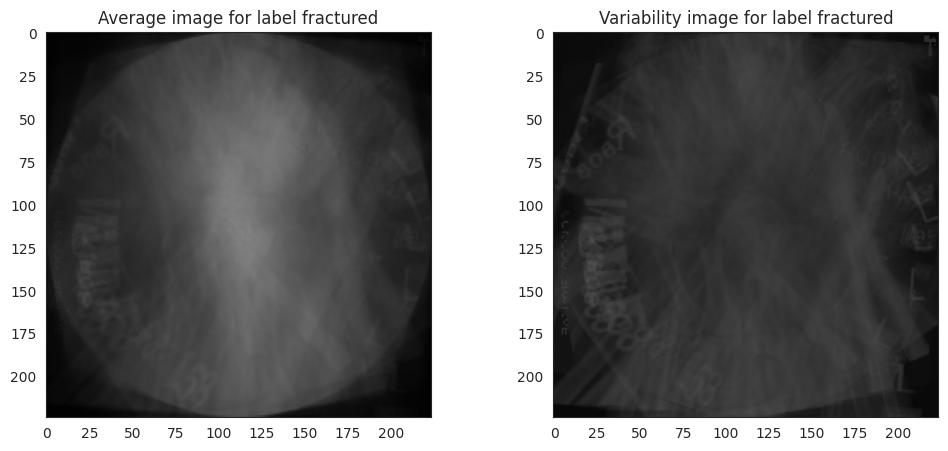

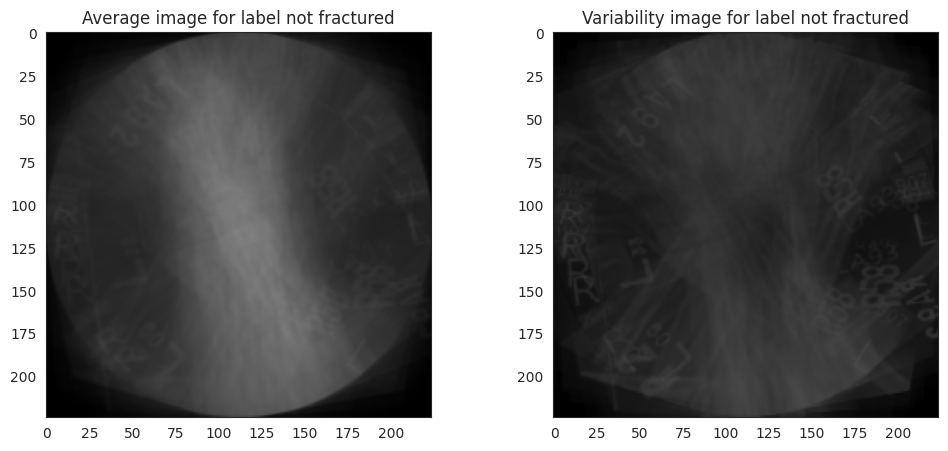

In [ ]:
plot_mean_variability_per_labels(X=X, y=y, figsize=(12, 5), save_image=True)

In [ ]:
def subset_image_label(X, y, label_to_display):
    y = y.reshape(-1, 1, 1)
    boolean_mask = np.any(y == label_to_display, axis=1).reshape(-1)
    return X[boolean_mask]



def diff_bet_avg_image_labels_data_as_array(X, y, label_1, label_2, figsize=(20, 5), save_image=False):
    if not os.path.exists(my_data_dir):
        raise ValueError (f"Directory {my_data_dir} doesnt exsist in files")
    sns.set_style("white")

    if (label_1 not in np.unique(y)) or (label_2 not in np.unique(y)):
        print(
            f"Either label {label} or label {label_2}, are not in {np.unique(y)} ")
        return
    images_label = subset_image_label(X, y, label_1)
    label1_avg = np.mean(subset_image_label,(X, y, label_1), axis=0)
    label2_avg = np.mean(subset_image_label, (X, y, label_1), axis =0)


    difference_mean = label1_avg - label2_avg
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=figsize)
    axes[0].imshow(label1_avg, cmap='gray')
    axes[0].set_title(f'Average {label_1}')
    axes[1].imshow(label2_avg, cmap='gray')
    axes[1].set_title(f'Average {label_2}')
    axes[2].imshow(difference_mean, cmap='gray')
    axes[2].set_title(f'Difference image: Avg {label_1} & {label_2}')
    if save_image:
        plt.savefig(f"{file_path}/avg_diff.png", bbox_inches='tight', dpi=150)
    else:
        plt.tight_layout()
        plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13490196391940118..0.19437909002105394].


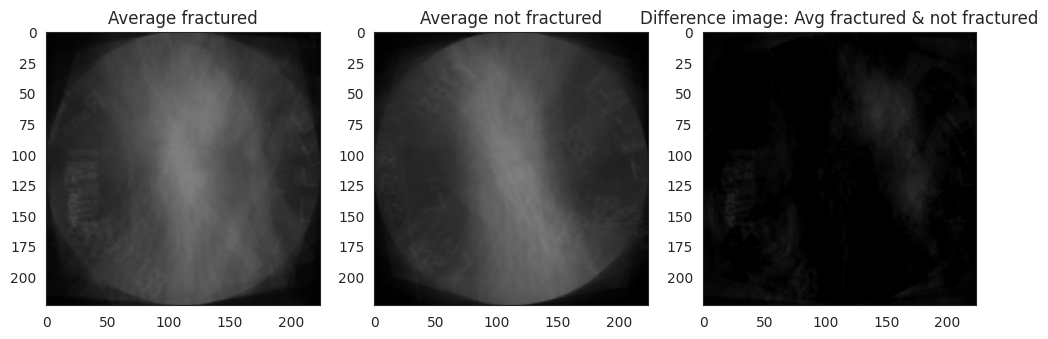

In [ ]:
diff_bet_avg_image_labels_data_as_array(X=X, y=y,
                                        label_1='fractured', label_2='not fractured',
                                        figsize=(12, 10),
                                        save_image=True
                                        )


In [45]:
import itertools
import random

sns.set_style("white")

def image_montage(dir_path, label_to_display, nrows, ncols, figsize=(15, 10)):
    labels = os.listdir(dir_path)
    if label_to_display in labels:
        images_list = os.listdir(os.path.join(dir_path, label_to_display))
        if nrows * ncols < len(images_list):
            img_idx = random.sample(images_list, nrows * ncols)
        else:
            print(
                f"Decrease num of row or num of cols to create your montage. \n"
                f"There are {len(images_list)} in your subset. "
                f"You requested a montage with {nrows * ncols} spaces")
            return
      
        plot_idx = list(itertools.product(range(nrows), range(ncols)))

        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
        for x in range(0, nrows*ncols):
            img = imread(dir_path + '/' + label_to_display + '/' + img_idx[x])
            img_shape = img.shape
            axes[plot_idx[x][0], plot_idx[x][1]].imshow(img)
            axes[plot_idx[x][0], plot_idx[x][1]].set_title(
                f"Width {img_shape[1]}px x Height {img_shape[0]}px")
            axes[plot_idx[x][0], plot_idx[x][1]].set_xticks([])
            axes[plot_idx[x][0], plot_idx[x][1]].set_yticks([])
        plt.tight_layout()
        plt.show()

    else:
        print("The label you selected doesn't exist.")
        print(f"The existing options are: {labels}")

fractured


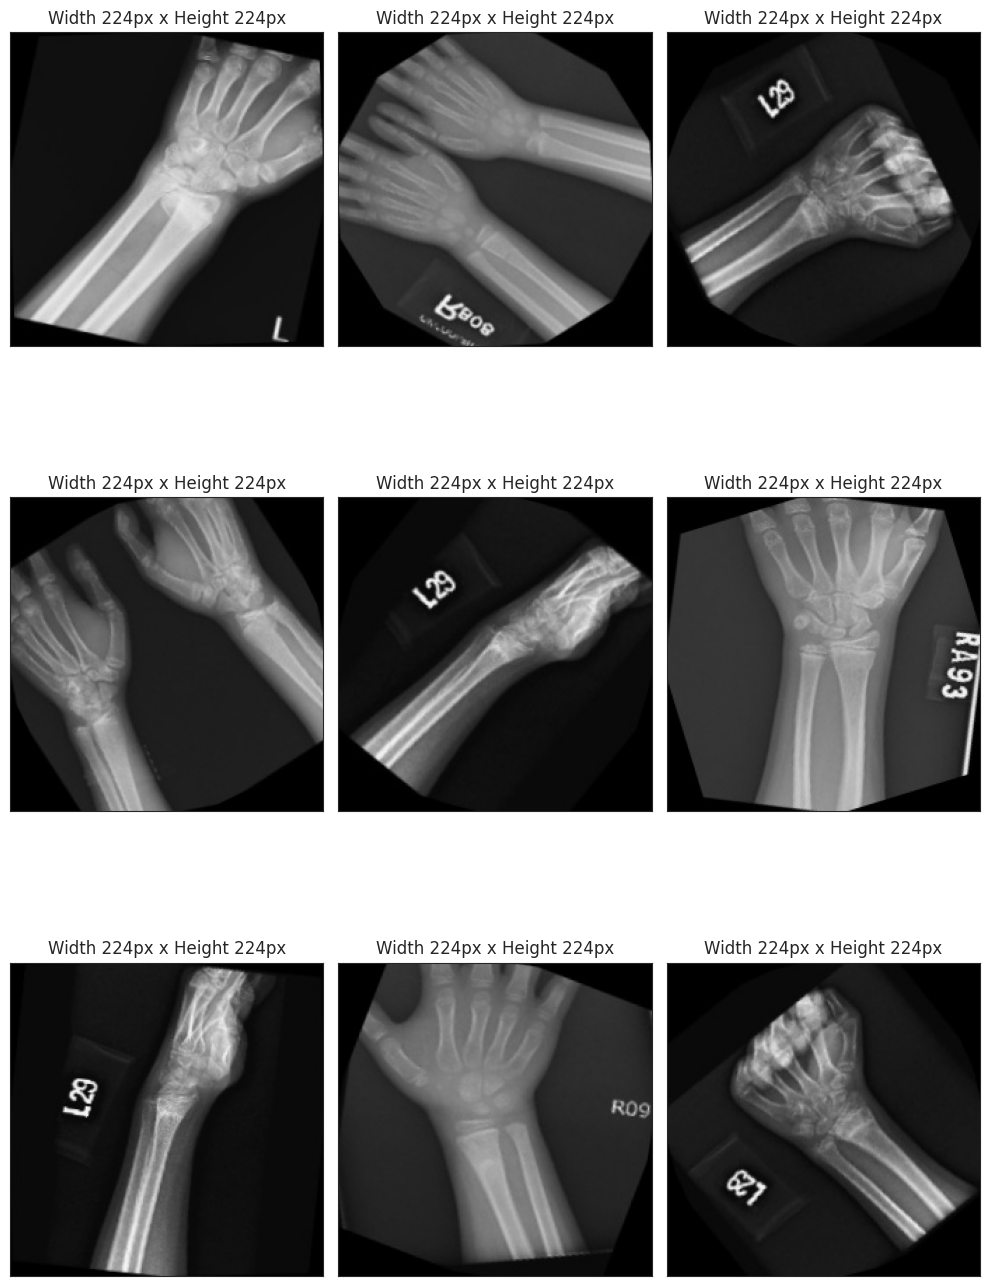



not fractured


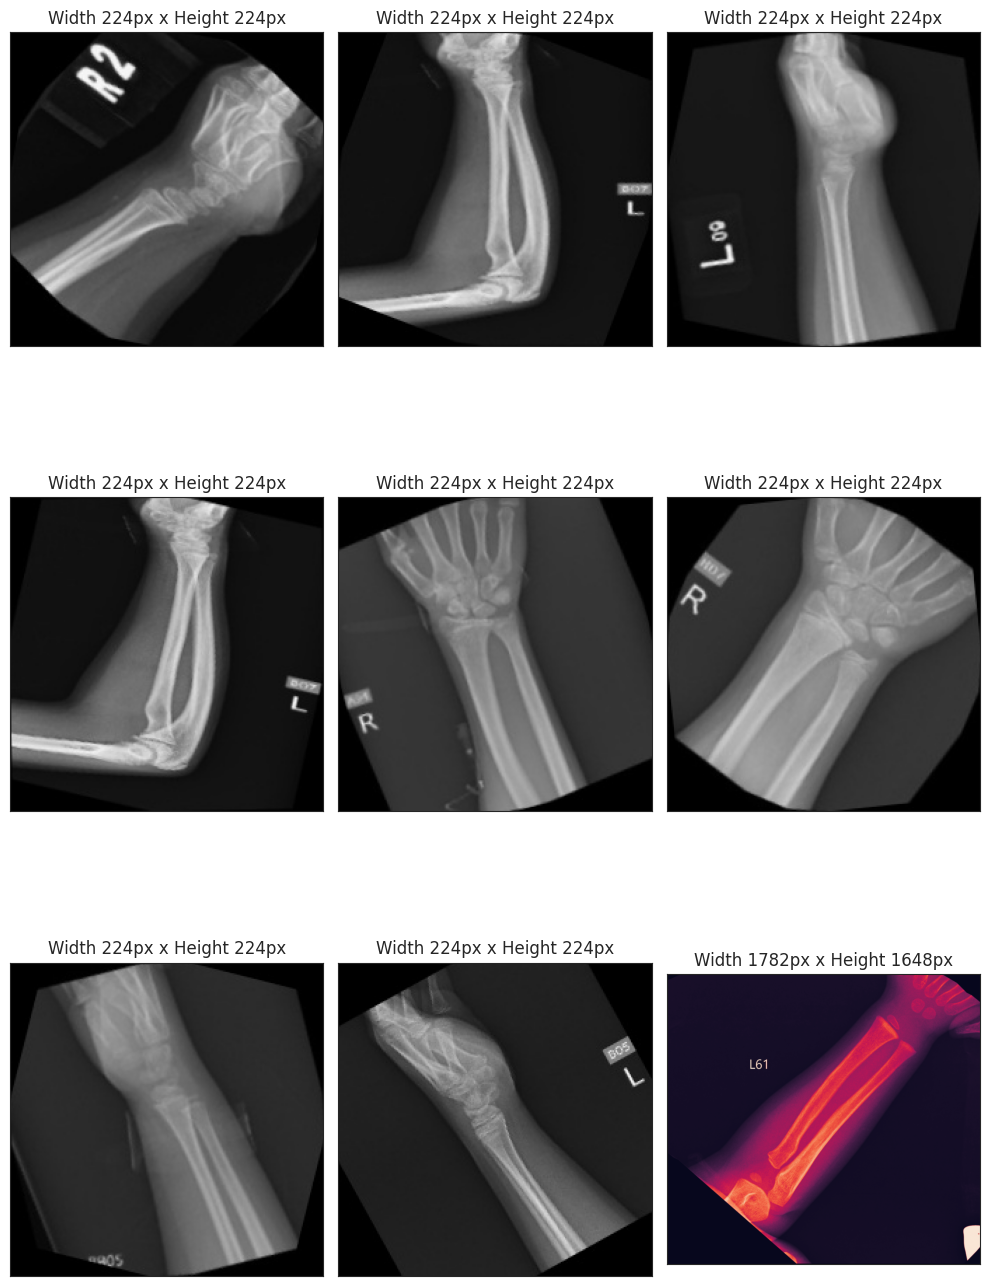

In [ ]:
for label in labels:
    print(label)
    image_montage(dir_path=train_path,
                  label_to_display=label,
                  nrows=3, ncols=3,
                  figsize=(10, 15)
                  )
    print("\n")